# Fourier transforms in Python on energy markets data
Following on from `fourier_transforms.ipynb`, let's now analyse some market data from the EU energy market. Specifically, we will use the "Monthly Hourly Load Values" aggregated hourly by country, accessed from https://www.entsoe.eu/data/power-stats/ as csv files. The data is stored locally in `../data/entsoe_power_stats`.

We want to see if we can 'de-noise' the data. Ideally, we can extract the hourly/daily/seasonal fluctuations, and what we are then left with is the 'noise' or residual data. What I would then like to do is find if there are physical drivers for this 'noise'.

Note, we do not 'clean' the data beyond fixing some indexing issues, we treat the raw data as a source of truth. Certainly there will be outliers to remove, but let's play with the raw data for now.

In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/processed/NL_hourly_load_2006-2025.csv')
df['DateUTC'] = pd.to_datetime(df['DateUTC'])
df.set_index('DateUTC', inplace=True)

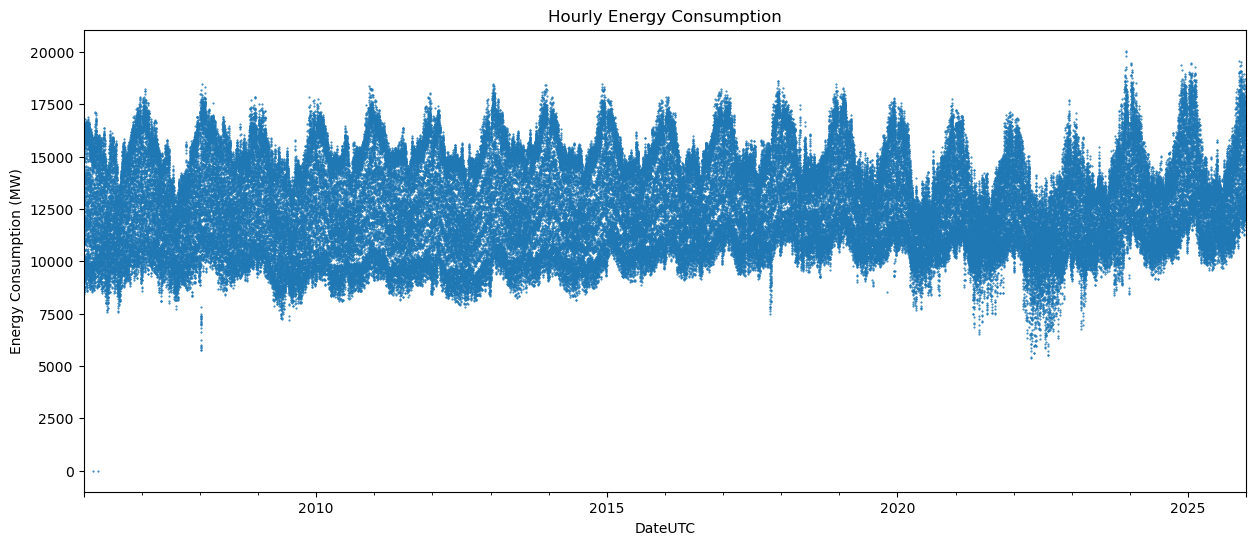

In [3]:
# Plot the hourly energy consumption
df['Load'].plot(style='.', figsize=(15, 6), title='Hourly Energy Consumption', markersize=1)
plt.ylabel('Energy Consumption (MW)')
plt.show()

In [4]:
# Because the data pre-2015 is not standardised in time, let's ignore it for now and only use the data from 2015 onwards. We can always add the pre-2015 data later if we want to.
df = df[df.index >= '2015-01-01'].copy()

There are 1 missing values in the dataset. Linearly interpolating missing values.


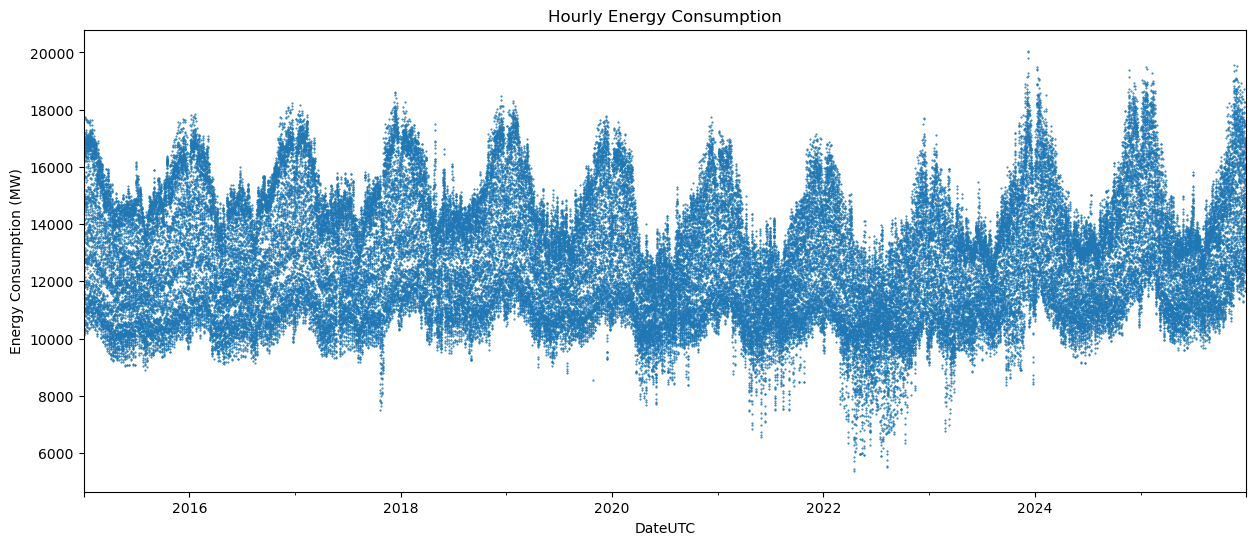

In [5]:
# Check for missing values
if df.isnull().sum().values[0] > 0:
    print(f"There are {df.isnull().sum().values[0]} missing values in the dataset. Linearly interpolating missing values.")
    # Interpolate NaN values to the mean of left and right values
    df['Load'] = df['Load'].interpolate(method='linear')

# Take out the obvious outliers using a rolling window of 1 week and a z-score threshold of 3
s = df['Load'].copy()
window = 24 * 7 # 1 week

rollingWindow = s.rolling(window=window, min_periods=1, center=True)
mean = rollingWindow.mean()
std = rollingWindow.std(ddof=0)
z = s.sub(mean).div(std)

m = z.between(-3, 3)
df['Load'] = s.where(m, np.nan).interpolate(method='linear')

# Plot the hourly energy consumption
df['Load'].plot(style='.', figsize=(15, 6), title='Hourly Energy Consumption', markersize=1)
plt.ylabel('Energy Consumption (MW)')
plt.show()

In [6]:
df.iloc[0], df.iloc[-1]

(Load    11586.0
 Name: 2015-01-01 00:00:00, dtype: float64,
 Load    12769.99
 Name: 2025-12-31 23:00:00, dtype: float64)

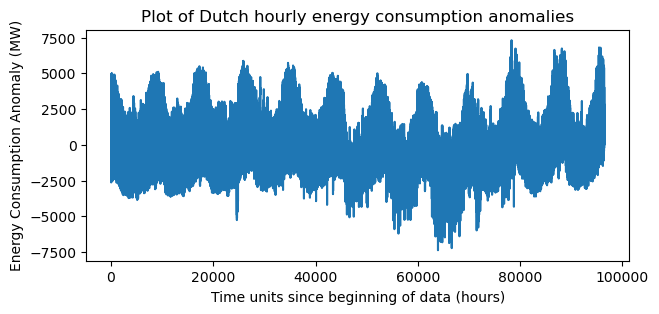

In [7]:
# Perfect, now we can drop the old DateUTC index and just use the new one. Let's now play with the data, just like before.
# Let's create a centered version of the data to make it easier to see the patterns in the data.
x = df['Load'].values - df['Load'].values.mean()
N = len(x)

plt.figure(figsize=(7, 3))
plt.plot(x)
plt.xlabel('Time units since beginning of data (hours)')
plt.ylabel('Energy Consumption Anomaly (MW)')
plt.title('Plot of Dutch hourly energy consumption anomalies')
plt.show()

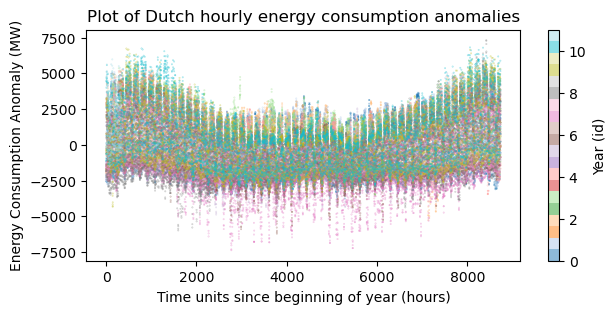

In [8]:
# Split into yearly data (52*7 = 364 days per year, 24 hours per day)

plt.figure(figsize=(7, 3))
plt.scatter(np.arange(0,len(x))%(364*24),x, c=np.arange(0,len(x))//(364*24), s=0.1, alpha=0.5, cmap='tab20')
plt.xlabel('Time units since beginning of year (hours)')
plt.ylabel('Energy Consumption Anomaly (MW)')
plt.colorbar(label='Year (id)')
plt.title('Plot of Dutch hourly energy consumption anomalies')
plt.show()

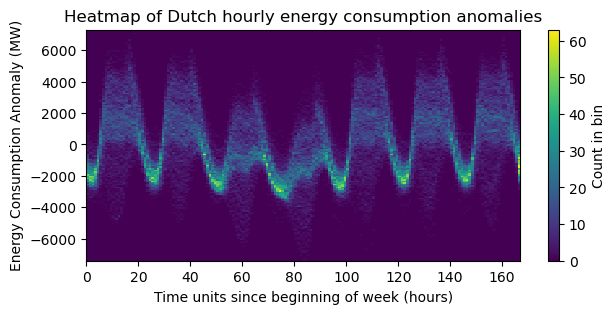

In [9]:
# Weekly histogram Split into yearly data (52*7 = 364 days per year, 24 hours per day)

plt.figure(figsize=(7, 3))
plt.hist2d(np.arange(0,len(x))%(7*24),x, bins=[np.arange(0,7*24,1), np.arange(-7400,7400,100)])
plt.xlabel('Time units since beginning of week (hours)')
plt.ylabel('Energy Consumption Anomaly (MW)')
plt.colorbar(label='Count in bin')
plt.title('Heatmap of Dutch hourly energy consumption anomalies')
plt.show()

What this tells me without computing any statistics, is that overnight is relatively easy to predict (frequently in the same bin), whereas there is a lot more variability during the days. We could split this up into monthly/seasonal plots too, that can be in another notebook.

/Users/michael/miniconda3/envs/BalancePredict/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/michael/miniconda3/envs/BalancePredict/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


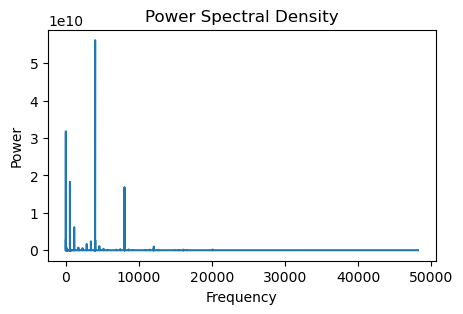

In [10]:
# Perform an FFT (a particular implementation of the DFT) on the signal
X = sp.fft.fft(x)
frequencies = sp.fft.fftfreq(x.shape[-1], d=1/N)  # Get the corresponding frequencies

# Compute the power spectral density (PSD) of the signal
psd = np.conj(X) * X / N # Peaks in this array correspond to the dominant frequencies in the signal

# Plot the PSD
plt.figure(figsize=(5, 3))
plt.plot(frequencies[:N//2], psd[:N//2])  # Plot only the positive frequencies
plt.xlabel('Frequency')
plt.ylabel('Power')
plt.title('Power Spectral Density')
plt.show()

There are quite a few peaks in there. Let's start with extracting the more prominent frequencies, and then see if adding the other frequencies can improve our reconstruction.

In [11]:
peak_ids, peak_vals = sp.signal.find_peaks(np.abs(psd), height=0.2e10)  # Find peaks in the FFT with a minimum height threshold
dominant_frequencies = frequencies[peak_ids]
print(f'Dominant frequencies: {dominant_frequencies}')
print(f'Number of dominant frequencies: {len(dominant_frequencies)//2}')

Dominant frequencies: [ 1.000e+00  1.100e+01  2.200e+01  5.740e+02  1.148e+03  3.444e+03
  4.007e+03  4.018e+03  4.029e+03  8.036e+03 -8.036e+03 -4.029e+03
 -4.018e+03 -4.007e+03 -3.444e+03 -1.148e+03 -5.740e+02 -2.200e+01
 -1.100e+01]
Number of dominant frequencies: 9


/Users/michael/miniconda3/envs/BalancePredict/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/michael/miniconda3/envs/BalancePredict/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


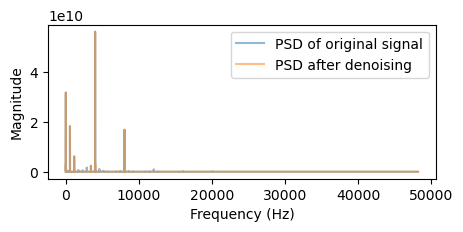

In [12]:
X_denoised = np.zeros_like(X)
X_denoised[peak_ids] = X[peak_ids]  # Keep only the dominant frequency component
# Note, the peak ids already include the negative frequencies as well

psd_denoised = np.conj(X_denoised) * X_denoised / N

plt.figure(figsize=(5, 2))
plt.plot(frequencies[:N//2], psd[:N//2], label='PSD of original signal', alpha=0.5)  # Plot only the positive frequencies
plt.plot(frequencies[:N//2], psd_denoised[:N//2], label='PSD after denoising', alpha=0.5)  # Plot only the positive frequencies
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.legend()
plt.show()

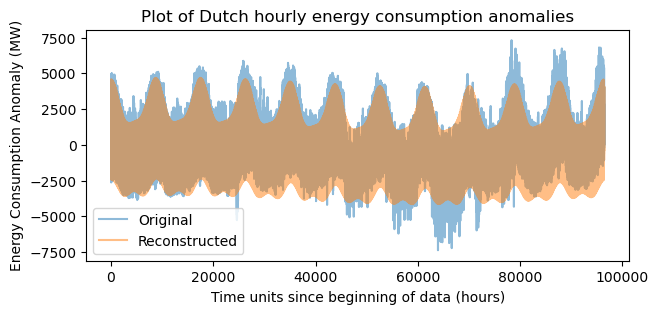

In [13]:
# Reconstruct the signal from the denoised FFT
x_denoised = sp.fft.ifft(X_denoised)

plt.figure(figsize=(7, 3))
plt.plot(x, label='Original', alpha=0.5)
plt.plot(x_denoised.real, label='Reconstructed', alpha=0.5)
plt.xlabel('Time units since beginning of data (hours)')
plt.ylabel('Energy Consumption Anomaly (MW)')
plt.title('Plot of Dutch hourly energy consumption anomalies')
plt.legend()
plt.show()

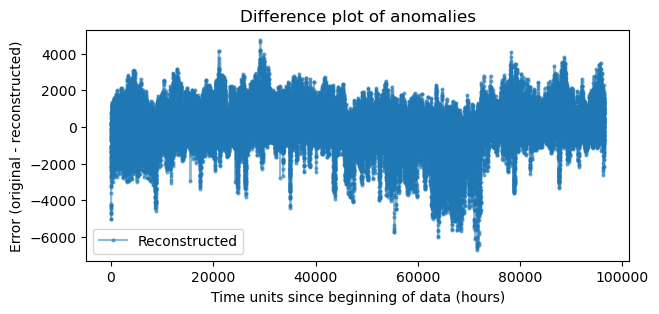

In [14]:
# Reconstruct the signal from the denoised FFT
x_denoised = sp.fft.ifft(X_denoised)

plt.figure(figsize=(7, 3))
plt.plot(x - x_denoised.real, label='Reconstructed', marker='o', markersize=2,alpha=0.5)
plt.xlabel('Time units since beginning of data (hours)')
plt.ylabel('Error (original - reconstructed)')
plt.title('Difference plot of anomalies')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Histogram of differences between original and reconstructed anomalies')

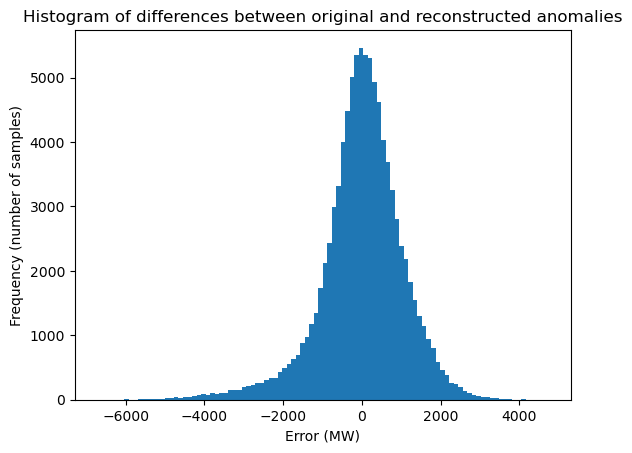

In [15]:
plt.hist(x - x_denoised.real, bins=100)
plt.xlabel('Error (MW)')
plt.ylabel('Frequency (number of samples)')
plt.title('Histogram of differences between original and reconstructed anomalies')

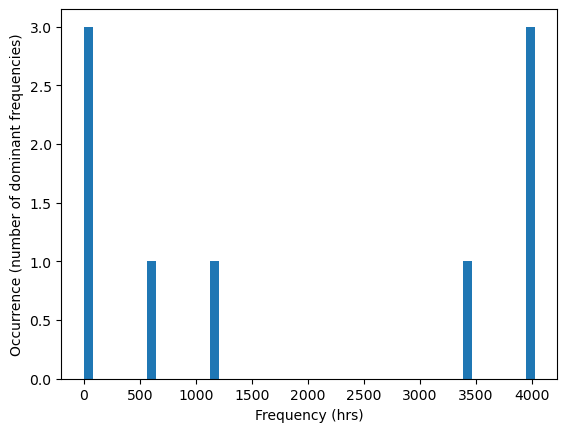

In [16]:
plt.hist(dominant_frequencies[:len(dominant_frequencies)//2], bins=50)  # Plot only the positive frequencies
plt.xlabel('Frequency (hrs)')
plt.ylabel('Occurrence (number of dominant frequencies)')
plt.show()

In [17]:
# Store this reconstructed signal for later comparison
x_denoised_handpicked = x_denoised.real

### What if we use more frequencies (corresponding to the smaller peaks) in the PSD?
Let's use all frequencies that are above the 95th percentile of the PSD values

Number of dominant frequencies: 2411


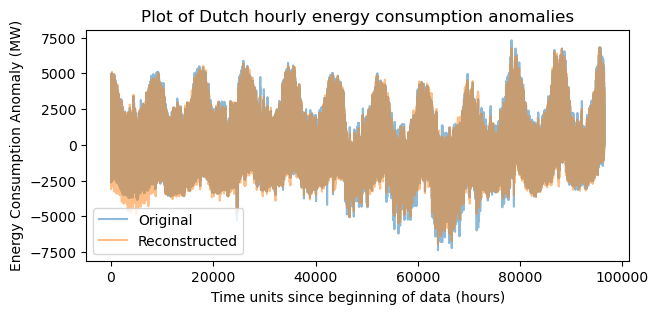

In [18]:
# What if we use more frequencies (corresponding to the smaller peaks in the PSD?
# Let's use all frequencies that are above the 95th percentile of the PSD values
threshold = np.percentile(np.abs(psd[:N//2]), 95)
peak_ids = np.where(np.abs(psd) > threshold)[0]
dominant_frequencies = frequencies[peak_ids]
print(f'Number of dominant frequencies: {len(dominant_frequencies)//2}')

X_denoised = np.zeros_like(X)
X_denoised[peak_ids] = X[peak_ids]  # Keep only the dominant frequency component

# Reconstruct the signal from the denoised FFT
x_denoised = sp.fft.ifft(X_denoised)

plt.figure(figsize=(7, 3))
plt.plot(x, label='Original', alpha=0.5)
plt.plot(x_denoised.real, label='Reconstructed', alpha=0.5)
plt.xlabel('Time units since beginning of data (hours)')
plt.ylabel('Energy Consumption Anomaly (MW)')
plt.title('Plot of Dutch hourly energy consumption anomalies')
plt.legend()
plt.show()

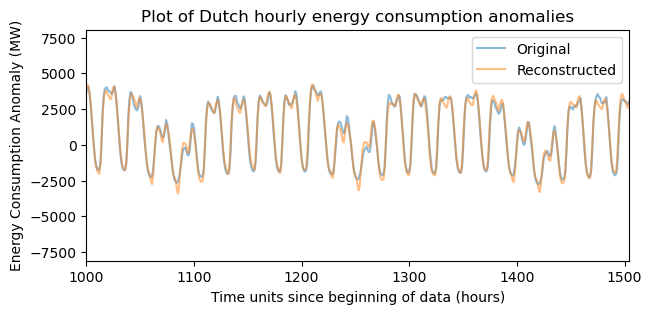

In [19]:
plt.figure(figsize=(7, 3))
plt.plot(x, label='Original', alpha=0.5)
plt.plot(x_denoised.real, label='Reconstructed', alpha=0.5)
plt.xlabel('Time units since beginning of data (hours)')
plt.ylabel('Energy Consumption Anomaly (MW)')
plt.title('Plot of Dutch hourly energy consumption anomalies')
plt.legend()
plt.xlim(1000, 1000+3*24*7)
plt.show()

Text(0.5, 1.0, 'Histogram of differences between original and reconstructed anomalies')

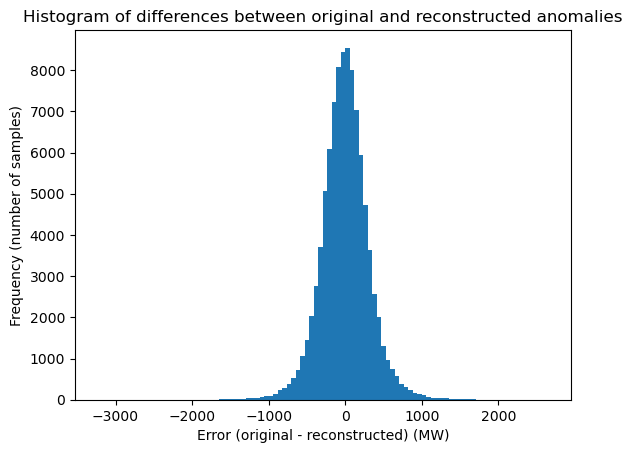

In [20]:
plt.hist(x - x_denoised.real, bins=100)
plt.xlabel('Error (original - reconstructed) (MW)')
plt.ylabel('Frequency (number of samples)')
plt.title('Histogram of differences between original and reconstructed anomalies')

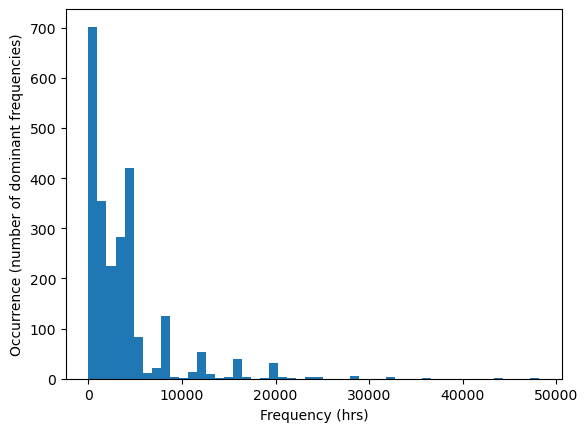

In [21]:
plt.hist(dominant_frequencies[:len(dominant_frequencies)//2], bins=50)  # Plot only the positive frequencies
plt.xlabel('Frequency (hrs)')
plt.ylabel('Occurrence (number of dominant frequencies)')
plt.show()

In [22]:
x_denoised_95 = x_denoised.real

By using the 95th percentile as a threshold, we are keeping more frequency components in the signal, which allows us to capture more of the original signal's variability. This results in a reconstructed signal that is closer to the original, and now our "error" is much smaller. However, this is likely a large "overfit" of the data...
Let's be a little more selective, and use the 99.9th percentile (i.e. keeping only the top 0.1% of the frequencies)

Number of dominant frequencies: 49


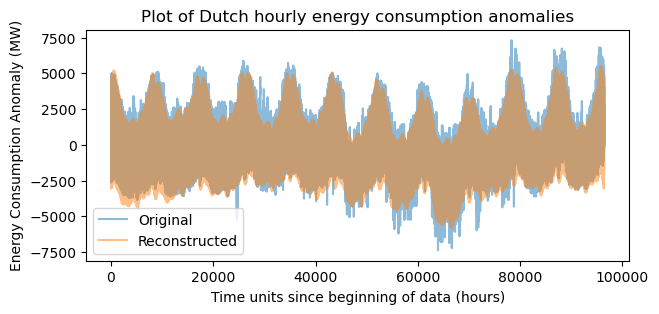

In [23]:
# What if we use more frequencies (corresponding to the smaller peaks in the PSD?
# Let's use all frequencies that are above the 99.9th percentile of the PSD values
threshold = np.percentile(np.abs(psd[:N//2]), 99.9)
peak_ids = np.where(np.abs(psd) > threshold)[0]
dominant_frequencies = frequencies[peak_ids]
print(f'Number of dominant frequencies: {len(dominant_frequencies)//2}')

X_denoised = np.zeros_like(X)
X_denoised[peak_ids] = X[peak_ids]  # Keep only the dominant frequency component

# Reconstruct the signal from the denoised FFT
x_denoised = sp.fft.ifft(X_denoised)

plt.figure(figsize=(7, 3))
plt.plot(x, label='Original', alpha=0.5)
plt.plot(x_denoised.real, label='Reconstructed', alpha=0.5)
plt.xlabel('Time units since beginning of data (hours)')
plt.ylabel('Energy Consumption Anomaly (MW)')
plt.title('Plot of Dutch hourly energy consumption anomalies')
plt.legend()
plt.show()

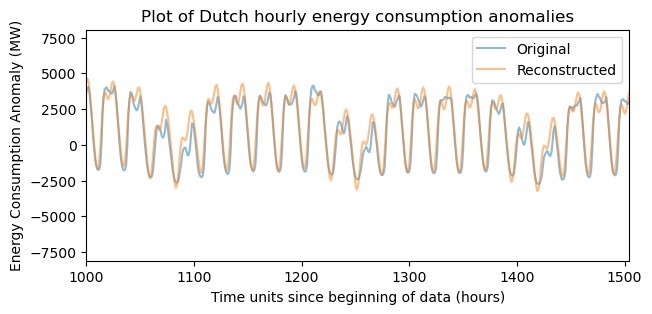

In [24]:
plt.figure(figsize=(7, 3))
plt.plot(x, label='Original', alpha=0.5)
plt.plot(x_denoised.real, label='Reconstructed', alpha=0.5)
plt.xlabel('Time units since beginning of data (hours)')
plt.ylabel('Energy Consumption Anomaly (MW)')
plt.title('Plot of Dutch hourly energy consumption anomalies')
plt.legend()
plt.xlim(1000, 1000+3*24*7)
plt.show()

Text(0.5, 1.0, 'Histogram of differences between original and reconstructed anomalies')

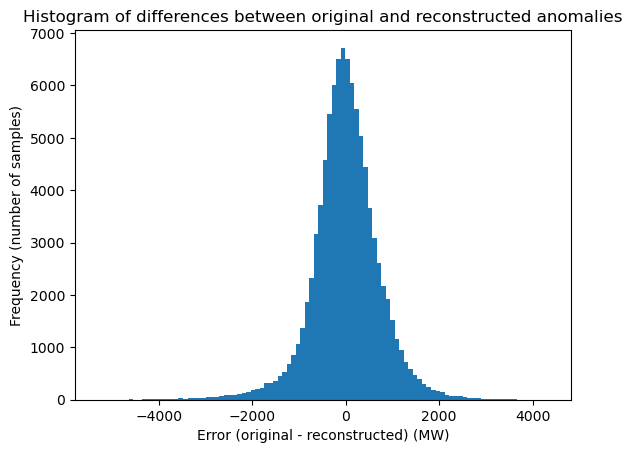

In [25]:
plt.hist(x - x_denoised.real, bins=100)
plt.xlabel('Error (original - reconstructed) (MW)')
plt.ylabel('Frequency (number of samples)')
plt.title('Histogram of differences between original and reconstructed anomalies')

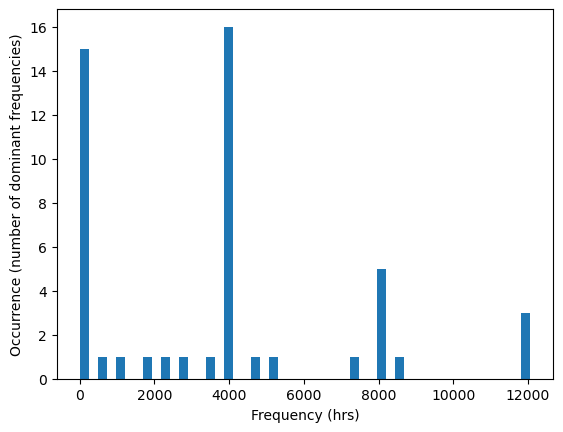

In [26]:
plt.hist(dominant_frequencies[:len(dominant_frequencies)//2], bins=50)  # Plot only the positive frequencies
plt.xlabel('Frequency (hrs)')
plt.ylabel('Occurrence (number of dominant frequencies)')
plt.show()

In [27]:
x_denoised_99 = x_denoised.real

### Compare the handpicked with the 95th percentile and 99.9th percentile reconstructions

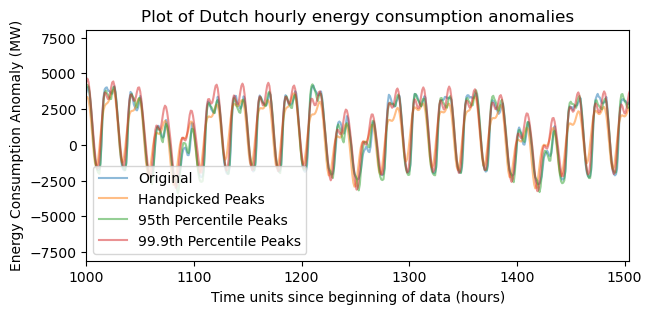

In [28]:
# Compare the handpicked with the 95th percentile and 99.9th percentile reconstructions
plt.figure(figsize=(7, 3))
plt.plot(x, label='Original', alpha=0.5)
plt.plot(x_denoised_handpicked, label='Handpicked Peaks', alpha=0.5)
plt.plot(x_denoised_95, label='95th Percentile Peaks', alpha=0.5)
plt.plot(x_denoised_99, label='99.9th Percentile Peaks', alpha=0.5)
plt.xlabel('Time units since beginning of data (hours)')
plt.ylabel('Energy Consumption Anomaly (MW)')
plt.title('Plot of Dutch hourly energy consumption anomalies')
plt.xlim(1000, 1000+3*24*7)
plt.legend()
plt.show()

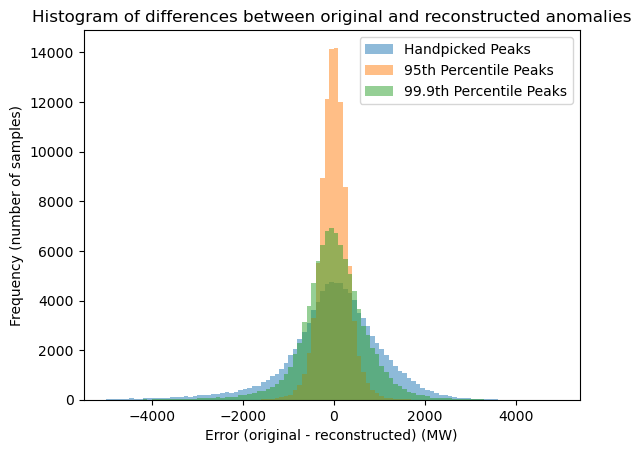

RMSE of handpicked peaks reconstruction: 1057.82 MW
RMSE of 95th percentile peaks reconstruction: 310.07 MW
RMSE of 99.9th percentile peaks reconstruction: 726.06 MW


In [29]:
plt.hist(x - x_denoised_handpicked, bins=np.arange(-5000,5000,100), alpha=0.5, label='Handpicked Peaks')
plt.hist(x - x_denoised_95, bins=np.arange(-5000,5000,100), alpha=0.5, label='95th Percentile Peaks')
plt.hist(x - x_denoised_99, bins=np.arange(-5000,5000,100), alpha=0.5, label='99.9th Percentile Peaks')

plt.xlabel('Error (original - reconstructed) (MW)')
plt.ylabel('Frequency (number of samples)')
plt.title('Histogram of differences between original and reconstructed anomalies')
plt.legend()
plt.show()

# RMSE
rmse_handpicked = np.sqrt(np.mean((x - x_denoised_handpicked)**2))
rmse_95 = np.sqrt(np.mean((x - x_denoised_95)**2))
rmse_99 = np.sqrt(np.mean((x - x_denoised_99)**2))

print(f'RMSE of handpicked peaks reconstruction: {rmse_handpicked:.2f} MW')
print(f'RMSE of 95th percentile peaks reconstruction: {rmse_95:.2f} MW')
print(f'RMSE of 99.9th percentile peaks reconstruction: {rmse_99:.2f} MW')

The handpicked reconstruction uses only 9 frequencies, whereas the 99.9th percentile choice uses 27 (20 additional frequencies). The 95th percentile uses a whopping 1316 frequencies, it's definitely an overfit. I think the 99.9th percentile choice is reasonable, so the next step will be to try and learn the residuals, and see if we can identify physical and temporal drivers of the residuals.